# CIENCIA DE LA COMPUTACION
### Facultad de Ciencias 
---
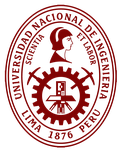
---

### Curso: Minería de Datos (CC442A)
### Profesor: Dr. Marco Antonio Alania Vicente

---
---
## Laboratorio 1: Fundamentos Geométricos y KDD (Desde Cero)
---
---

**Objetivo:** Implementar los fundamentos matemáticos del análisis multidimensional (centro de gravedad, dispersión y métricas topológicas) utilizando exclusivamente álgebra lineal con `numpy`.

**Nota para la Exposición:** Cada estudiante analizará un dataset único basado en su código de estudiante. Deberán explicar la lógica matemática de su código sin depender de librerías de alto nivel.

## 1. Configuración del Entorno y Asignación de Datos
Ingrese su código de estudiante. Este número actuará como una semilla aleatoria (`random seed`) inmutable. Según su código, el sistema le asignará uno de tres dominios científicos reales para su análisis.

In [ ]:
import numpy as np

# ==========================================
# INGRESE SU CÓDIGO DE ESTUDIANTE AQUÍ
CODIGO_ESTUDIANTE = 20215508  # Reemplace por su código
# ==========================================

np.random.seed(CODIGO_ESTUDIANTE)
dataset_id = CODIGO_ESTUDIANTE % 3

if dataset_id == 0:
    dominio = 'Astrofísica: Espectrometría de Cuásares y Galaxias'
    caracteristicas = ['Redshift', 'Luminosidad', 'Ancho de línea', 'Flujo de Rayos X']
elif dataset_id == 1:
    dominio = 'Ciencia Computacional: Dinámica Molecular de Nanopartículas (Simulación LAMMPS)'
    caracteristicas = ['Energía cinética', 'Energía potencial', 'Presión', 'Temperatura']
else:
    dominio = 'Salud Pública: Detección Temprana de Sepsis en UCI'
    caracteristicas = ['Presión arterial', 'Ritmo cardíaco', 'Temperatura', 'Nivel de Leucocitos']

d = len(caracteristicas)
n = 500 # Número de instancias

print(f"--- ASIGNACIÓN DE LABORATORIO ---")
print(f"Estudiante: {CODIGO_ESTUDIANTE}")
print(f"Dominio de investigación: {dominio}")
print(f"Características a medir (d={d}): {caracteristicas}\n")

# Generación del dataset sintético estrictamente controlado por la semilla
X = np.random.randn(n, d) * np.random.uniform(2, 15, size=d) + np.random.uniform(-20, 100, size=d)
print(f"Dataset (Matriz X) generado con forma: {X.shape}")      

--- ASIGNACIÓN DE LABORATORIO ---
Estudiante: 20215508
Dominio de investigación: Salud Pública: Detección Temprana de Sepsis en UCI
Características a medir (d=4): ['Presión arterial', 'Ritmo cardíaco', 'Temperatura', 'Nivel de Leucocitos']

Dataset (Matriz X) generado con forma: (500, 4)


¿QUE ES LA SEPSIS EN UCI?

La sepsis es una respuesta extrema y potencialmente mortal del cuerpo a una infección, que puede causar daño a los organos y la muerte si no se trata a tiempo. Asi las caracteristicas mas relevante para el control si tiene un paciente sepsis son: 

* Presion Arterial

* Ritmo Cardiaco

* Temperatura

* Nivel de Leucocitos

In [26]:
print("Impresion de datos")
print(f"\n  P.Arterial  Ritm.Card   Temperatura Niv.Leuco ")
print(X)

Impresion de datos

  P.Arterial  Ritm.Card   Temperatura Niv.Leuco 
[[48.38171821 64.42404559 33.54543753 61.07808035]
 [51.50580316 62.91755068 27.14597308 51.7007953 ]
 [44.04999519 73.13727313 19.53661631 59.9519417 ]
 ...
 [52.32744526 60.75665767 23.64061951 65.12735921]
 [54.63269912 43.48425111 24.89284465 50.33528623]
 [55.37719255 61.02346239 28.57619174 68.4613294 ]]


In [27]:
print("\n--- CALCULOS PREVIOS ---")
print("Tamñao de la matriz X:", X.shape)
nn,mm=X.shape
print("Numero de registros:", nn)
print("Numero de atributos:", mm)


--- CALCULOS PREVIOS ---
Tamñao de la matriz X: (500, 4)
Numero de registros: 500
Numero de atributos: 4


## 2. Centro de Gravedad: Vector Media ($\mu$)
**Instrucciones:** Implemente la función matemática para calcular el vector media $\mu \in \mathbb{R}^d$.
*Restricción estricta:* Prohibido usar `np.mean`. Debe utilizar las propiedades matriciales iterativas o `np.sum` sobre el eje correspondiente, demostrando que entiende la fórmula teórica: $\mu = \frac{1}{n} \sum_{i=1}^{n} x_i$

## Definicion de vector media

Sea un conjunto de datos

$$
X=
\begin{pmatrix}
x_{11} & x_{12} & \cdots & x_{1d}\\
x_{21} & x_{22} & \cdots & x_{2d}\\
\vdots & \vdots & \ddots & \vdots\\
x_{n1} & x_{n2} & \cdots & x_{nd}
\end{pmatrix}
\in \mathbb{R}^{n\times d}
$$

El vector media(centro de gravedad) se define como

$$
\mu:=
\begin{pmatrix}
\mu_1\\
\mu_2\\
\vdots\\
\mu_d
\end{pmatrix} \in \mathbb{R}^{d\times 1},
\qquad
\mu_j:=\frac{1}{n}\sum_{i=1}^{n}x_{ij}
$$


In [28]:
def calcular_vector_media(X):
    """
    Calcula el vector media de una matriz de datos.
    matriz_X: numpy array de forma (n, d)
    Retorna: numpy array de forma (1,(d,))
    """
    n,m=X.shape
    vect=np.zeros(m)
    for i in range(n): 
        vect+=X[i,:]
    vect/=n
    return np.sum(vect)/m,vect

# Prueba de la función
mu,Vmed = calcular_vector_media(X)
print("Vector media calculado (Centro de gravedad):", Vmed)
print("Media de todos los datos calculado:", mu)

print("\nUsando libreria, vector media calculado (Centro de gravedad):", np.mean(X, axis=0 ))
print(f"Usando libreria, media de todos los datos: {np.mean(X)}")

Vector media calculado (Centro de gravedad): [47.61671067 61.80610511 22.31676848 59.47310074]
Media de todos los datos calculado: 47.803171251425916

Usando libreria, vector media calculado (Centro de gravedad): [47.61671067 61.80610511 22.31676848 59.47310074]
Usando libreria, media de todos los datos: 47.80317125142593


## 3. Dispersión: Matriz de Covarianza ($\Sigma$)
**Instrucciones:** Implemente el cálculo de la matriz de covarianza $\Sigma = \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)(x_i - \mu)^T$.
*Restricción estricta:* Prohibido usar `np.cov`. Debe realizar el centrado de los datos y la multiplicación matricial correspondiente (`np.dot` o el operador `@`).

### Definicion de matriz de covarianza

Sea un conjunto de datos

$$
X=
\begin{pmatrix}
x_{11} & x_{12} & \cdots & x_{1d}\\
x_{21} & x_{22} & \cdots & x_{2d}\\
\vdots & \vdots & \ddots & \vdots\\
x_{n1} & x_{n2} & \cdots & x_{nd}
\end{pmatrix}
\in \mathbb{R}^{n\times d}
$$

donde cada fila

$$
x_i:=
\begin{pmatrix}
x_{i1}\\
x_{i2}\\
\vdots\\
x_{id}
\end{pmatrix}
\in \mathbb{R}^{d\times 1}
$$

representa una observacion(medicion) y cada columna representa una caracteristica.

El vector media se definio como

$$
\mu=
\begin{pmatrix}
\mu_1\\
\mu_2\\
\vdots\\
\mu_d
\end{pmatrix} \in \mathbb{R}^{d\times 1},
\qquad
\mu_j=\frac{1}{n}\sum_{i=1}^{n}x_{ij}
$$

La matriz de covarianza se define como

$$
\boxed{
\Sigma:=
\frac{1}{n}
\sum_{i=1}^{n}
(x_i-\mu)(x_i-\mu)^T
}
$$

donde

$$
\Sigma\in\mathbb{R}^{d\times d}
$$

Cada elemento de la matriz está dado por

$$
\boxed{
\Sigma_{jk}
=
\frac{1}{n}
\sum_{i=1}^{n}
(x_{ij}-\mu_j)(x_{ik}-\mu_k)
}
$$

Los elementos de la diagonal representan las varianzas de cada característica:

$$
\Sigma_{jj}
=
\frac{1}{n}
\sum_{i=1}^{n}
(x_{ij}-\mu_j)^2
=
\operatorname{Var}(X_j)
$$

Donde:

-$X_j$: es la caracteristicas $j$ , con todas sus mediciones

-$\operatorname{Var}(X_j)$: mide cuanto se dispersan los valores de la caracteristica $j$, respecto su media

Los elementos fuera de la diagonal representan las covarianzas entre pares de características:

$$
\Sigma_{jk}
=
\operatorname{Cov}(X_j,X_k)
$$

Por tanto,

$$
\Sigma=
\begin{pmatrix}
\operatorname{Var}(X_1) &
\operatorname{Cov}(X_1,X_2) &
\cdots &
\operatorname{Cov}(X_1,X_d)
\\
\operatorname{Cov}(X_2,X_1) &
\operatorname{Var}(X_2) &
\cdots &
\operatorname{Cov}(X_2,X_d)
\\
\vdots & \vdots & \ddots & \vdots
\\
\operatorname{Cov}(X_d,X_1) &
\operatorname{Cov}(X_d,X_2) &
\cdots &
\operatorname{Var}(X_d)
\end{pmatrix}
$$

Si definimos la matriz de datos centrados como

$$
X_c = X-\mathbf{1}\mu^T
$$

entonces la matriz de covarianza puede escribirse de forma matricial como

$$
\boxed{
\Sigma=\frac{1}{n}X_c^TX_c
}
$$

In [29]:
def calcular_matriz_covarianza(matriz_X, vector_mu):
    """
    Calcula la matriz de covarianza.
    matriz_X: numpy array de forma (n, d)
    vector_mu: numpy array de forma (d,)
    Retorna: numpy array de forma (d, d)
    """
    #dimension de la matriz
    n, d = matriz_X.shape
    # centramos cada observacion: x_i - mu
    X_c = matriz_X - vector_mu #matriz - vector fila(resta a cada fila) 
    # sigma = (1/n) * X_c^T X_c
    matriz_covarianza = (X_c.T @ X_c) / n
    
    return matriz_covarianza

_,mu = calcular_vector_media(X)
# Prueba de la función
Sigma = calcular_matriz_covarianza(X, mu)
print("Matriz de Covarianza calculada (Dispersión):\n", Sigma)
print("\nMatriz covarianza usando libreria:\n",np.cov(X.T,bias=True))

Matriz de Covarianza calculada (Dispersión):
 [[29.27306209  1.481295    1.02050087  1.46051869]
 [ 1.481295   94.4341883   1.11293559  0.39198192]
 [ 1.02050087  1.11293559 56.18311289 -0.40040092]
 [ 1.46051869  0.39198192 -0.40040092 34.33862259]]

Matriz covarianza usando libreria:
 [[29.27306209  1.481295    1.02050087  1.46051869]
 [ 1.481295   94.4341883   1.11293559  0.39198192]
 [ 1.02050087  1.11293559 56.18311289 -0.40040092]
 [ 1.46051869  0.39198192 -0.40040092 34.33862259]]


## 4. Topología del Espacio: Distancia de Minkowski
**Instrucciones:** Implemente la función matemática generalizada de la distancia de Minkowski.
*Restricción estricta:* Prohibido usar `scipy.spatial.distance` o la norma preconstruida `np.linalg.norm`.

Fórmula: $d(i,j) = \sqrt[h]{|x_{i1} - x_{j1}|^h + \dots + |x_{id} - x_{jd}|^h}$

## Espacio metrico

Sea $V$ un espacio vectorial con cuerpo en $K$. Una función

$$
d:V\times V\to \mathbb{K}
$$

se llama metrica si para todo $x,y,z\in V$ cumple:

1. $d(x,y)\geq 0$

2. $d(x,y)=0 \iff x=y$

3. $d(x,y)=d(y,x)$

4. $d(x,z)\leq d(x,y)+d(y,z)$

Entonces el par $(V,d)$,se denomina espacio metrico.

Para nuestro caso, tomando $V=\mathbb{R}^n$ y $\mathbb{K}=\mathbb{R}$, la distancia de Minkowski de orden $h\geq 1$, para dos puntos $x=(x_1,\ldots,x_n), \,\, y=(y_1,\ldots,y_n)$ se define como

$$
d_h(x,y)=\sqrt[h]{|x_1-y_1|^h+\cdots+|x_n-y_n|^h}=\left(\sum_{i=1}^{n}|x_i-y_i|^h\right)^{1/h}
$$

Por tanto, $(\mathbb{R}^n,d_h)$ es un espacio metrico para todo $h\geq 1$

Casos particulares:

1. $h=1$: distancia Manhattan, dada por
$$
d_1(x,y)=\sum_{i=1}^{n}|x_i-y_i|
$$

2. $h=2$: distancia Euclidiana, dada por
$$
d_2(x,y)=\left(\sum_{i=1}^{n}|x_i-y_i|^2\right)^{1/2}
$$

3. $h\to\infty$: distancia de Chebyshev, dada por 
$$
d_\infty(x,y)=\max_{1\leq i\leq n}|x_i-y_i|
$$
---

### Norma asociada a la distancia de Minkowski

Se define la norma asociada a la métrica de Minkowski por

$$
\|x\|_h=d_h(x,0)
$$

Entonces,

$$
\|x\|_h
=
\left(\sum_{i=1}^{n}|x_i|^h\right)^{1/h},
\qquad h\geq 1
$$

Esta funcion satisface los axiomas de una norma, por lo que $(\mathbb{R}^n,\|\cdot\|_h)$ es un espacio vectorial normado.

De esta forma, la metrica de Minkowski puede expresarse como

$$
d_h(x,y)=\|x-y\|_h.
$$

Por tanto, la norma $\|\cdot\|_h$ es la norma de Minkowski asociada a la métrica $d_h$.

---
### Equivalencia de distancias en $\mathbb{R}^n$

Sean $(X,d_1)$ y $(X,d_2)$ dos espacios métricos sobre el mismo conjunto $X$. Se dice que las métricas $d_1$ y $d_2$ son **equivalentes** si existen constantes $c,C>0$ tales que

$$
c\,d_1(x,y)\leq d_2(x,y)\leq C\,d_1(x,y),
\qquad \forall x,y\in X.
$$

En espacios vectoriales de dimensión finita, todas las normas son equivalentes. Por tanto, las métricas inducidas por dichas normas también son equivalentes.

En particular, para las normas de Minkowski $\|\cdot\|_p$ y $\|\cdot\|_q$ en $\mathbb{R}^n$,

$$
\|x\|_p \sim \|x\|_q.
$$

Esto implica que ambas métricas generan la misma noción de convergencia. Para una sucesión $(x_k)$,

$$
x_k\to x
\iff
\|x_k-x\|_p\to 0
\iff
\|x_k-x\|_q\to 0.
$$

Asi una sucesión converge respecto de la distancia Manhattan si y solo si converge respecto de la distancia Euclidiana.

Sin embargo, las distancias numericas pueden ser diferentes. Por ello, en algoritmos basados en distancias, la eleccion de la metrica puede modificar los vecinos mas cercanos, los agrupamientos y, en general, los resultados obtenidos.


In [30]:
def distancia_minkowski(x1, x2, h):
    """
    Calcula la distancia de Minkowski entre dos vectores individuales.
    x1, x2: numpy arrays de forma (d,)
    h: parámetro escalar numérico de la distancia (h >= 1)
    """
    return (np.sum((np.abs(x1-x2))**h))**(1/h)

# Prueba de la función con la primera instancia (índice 0) y el centro de gravedad (mu)
dist_manhattan = distancia_minkowski(X[0], mu, h=1)
dist_euclidiana = distancia_minkowski(X[0], mu, h=2)
print(f"Distancia Manhattan al centro (X_0): {dist_manhattan}")
print(f"Distancia Euclidiana al centro (X_0): {dist_euclidiana}")

# Prueba de distancia usando libreria
from scipy.spatial.distance import cityblock, euclidean
dist_manhattan_libreria = cityblock(X[0],mu)
dist_euclidiana_libreria = euclidean(X[0],mu)
print(f"\nDistancia Manhattan al centro (X_0), con libreria: {dist_manhattan_libreria}")
print(f"Distancia Euclidiana al centro (X_0), con libreria: {dist_euclidiana_libreria}")

Distancia Manhattan al centro (X_0): 16.21659666516948
Distancia Euclidiana al centro (X_0): 11.666096903724421

Distancia Manhattan al centro (X_0), con libreria: 16.21659666516948
Distancia Euclidiana al centro (X_0), con libreria: 11.666096903724421


## 5. Aplicación KDD: Detección del Comportamiento Anómalo (Outlier)
Utilice el motor deductivo que ha construido paso a paso para recorrer todas las $n$ instancias de su matriz $X$.

**Misión:**
1. Encuentre la instancia (índice $i$) que tenga la **mayor** distancia Euclidiana ($h=2$) respecto al vector media ($\mu$).
2. Imprima las características de esa instancia.
3. En un bloque de texto final (Markdown), responda: Para el dominio que le fue asignado, ¿qué podría significar físicamente o en el mundo real que un registro se desvíe tanto del centro de gravedad?

In [48]:
n,_=X.shape
_,mu = calcular_vector_media(X)

max_dist = 0
outlier_idx = -1
for i in range(n):
   d=distancia_minkowski(X[i],mu, 2)
   if d > max_dist:
      max_dist=d
      outlier_idx=i
print(f"\n--- ALERTA DE ANOMALIA/SSIN LIBRERIA ---")
print(f"Índice del registro anómalo: {outlier_idx}")
print(f"Distancia Euclidiana registrada: {max_dist}")
print(f"Valores de las características ({caracteristicas}):")
print(X[outlier_idx])

############################################################
vect=np.zeros(n)
for i in range(n):
   d=distancia_minkowski(X[i],mu, 2)
   vect[i]=d

print(f"\n--- ALERTA DE ANOMALIA/USANDO LIBRERIA ---")
print(f"Índice del registro anómalo: {np.argmax(vect)}")
print(f"Distancia Euclidiana registrada: {distancia_minkowski(X[np.argmax(vect)],mu, 2)}")
print(f"Valores de las características ({caracteristicas}):")
print(X[np.argmax(vect)])


--- ALERTA DE ANOMALIA/SSIN LIBRERIA ---
Índice del registro anómalo: 53
Distancia Euclidiana registrada: 35.09846236097163
Valores de las características (['Presión arterial', 'Ritmo cardíaco', 'Temperatura', 'Nivel de Leucocitos']):
[35.94240332 30.03924573 31.21652121 56.77612931]

--- ALERTA DE ANOMALIA/USANDO LIBRERIA ---
Índice del registro anómalo: 53
Distancia Euclidiana registrada: 35.09846236097163
Valores de las características (['Presión arterial', 'Ritmo cardíaco', 'Temperatura', 'Nivel de Leucocitos']):
[35.94240332 30.03924573 31.21652121 56.77612931]


### Interpretación del Científico de Datos

Para el dominio asignado, Salud Pública: Detección Temprana de Sepsis en UCI, el registro con mayor distancia Euclidiana respecto al vector media representa al paciente cuya combinación de presión arterial, ritmo cardíaco, temperatura y nivel de leucocitos se aleja más del comportamiento promedio observado en las 500 instancias.

Una distancia elevada indica un patrón fisiológico atípico. En un contexto clínico, podría corresponder a alteraciones importantes en uno o varios signos, como  hipotensión, taquicardia, temperatura anormal o un nivel de leucocitos muy diferente al promedio. Por ello, este registro debería considerarse una observación prioritaria para revisión clínica.

Sin embargo, una distancia Euclidiana grande por sí sola no constituye un diagnóstico de sepsis; unicamente identifica una observacion que se aparta considerablemente del centro de gravedad del conjunto de datos.



--- ANALISIS DE DISTANCIAS ---
Media de las distancias: 13.6239
Desviación estándar: 5.3495


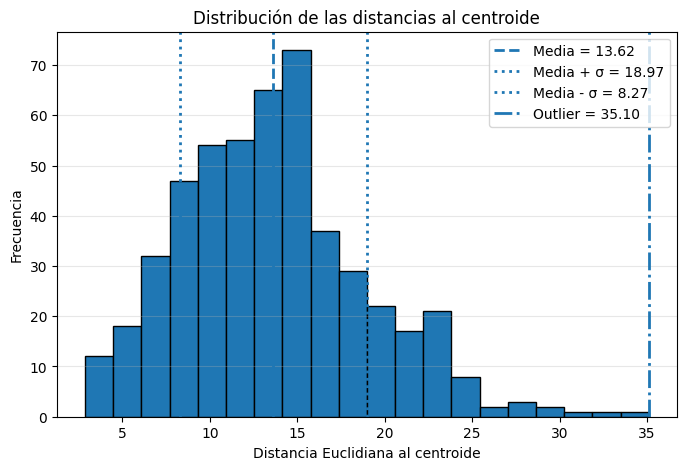

In [54]:
import numpy as np
import matplotlib.pyplot as plt
media = np.mean(vect)
desv_std = np.std(vect)
print("\n--- ANALISIS DE DISTANCIAS ---")
print(f"Media de las distancias: {media:.4f}")
print(f"Desviación estándar: {desv_std:.4f}")
# Histograma
plt.figure(figsize=(8, 5))
plt.hist(vect, bins=20, edgecolor="black")
# media
plt.axvline(
    media,
    linestyle="--",
    linewidth=2,
    label=f"Media = {media:.2f}"
)
# media ± desviacion estandar
plt.axvline(
    media + desv_std,
    linestyle=":",
    linewidth=2,
    label=f"Media + σ = {media + desv_std:.2f}"
)
plt.axvline(
    media - desv_std,
    linestyle=":",
    linewidth=2,
    label=f"Media - σ = {media - desv_std:.2f}"
)
# outlier
plt.axvline(
    max_dist,
    linestyle="-.",
    linewidth=2,
    label=f"Outlier = {max_dist:.2f}"
)

plt.xlabel("Distancia Euclidiana al centroide")
plt.ylabel("Frecuencia")
plt.title("Distribución de las distancias al centroide")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()